In [4]:
# Loading the data

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import folium
from folium.plugins import HeatMap
from sklearn.cluster import KMeans

# 1. Load your cleaned dataset
# Reading a sample of 10,000 rows to ensure maps render seamlessly in the browser
output_file = "cleaned_chicago_crimes.csv"
df = pd.read_csv(output_file, nrows=50000)

# 2. Extract key geospatial features
# Drop rows that might have corrupted lat/long strings during sample ingestion
df = df.dropna(subset=['Latitude', 'Longitude', 'District'])
df['District'] = df['District'].astype(int)

print(f"Successfully loaded {len(df)} rows for spatial visualization analytics.")
print(df[['Primary Type', 'Latitude', 'Longitude', 'District']].head())


Successfully loaded 50000 rows for spatial visualization analytics.
      Primary Type   Latitude  Longitude  District
0          ROBBERY  41.908417  -87.67741        14
1  CRIMINAL DAMAGE  41.886017  -87.63394         1
2            THEFT  41.871834  -87.62615         1
3         BURGLARY  41.856550  -87.69560        10
4      SEX OFFENSE  41.655117  -87.59489         5


In [5]:
# crime hotspot heatmap
# 1. Initialize a baseline Folium Map centered around Chicago coordinates
chicago_center = [41.8781, -87.6298]
hotspot_map = folium.Map(location=chicago_center, zoom_start=11, tiles="OpenStreetMap")

# 2. Extract coordinate matrices for the heat map engine
heat_data = df[['Latitude', 'Longitude']].values.tolist()

# 3. Inject the HeatMap plugin overlay
HeatMap(heat_data, radius=10, max_zoom=13).add_to(hotspot_map)

# 4. Display the interactive canvas map inside the notebook
hotspot_map






/tmp/ipykernel_3990/3086404322.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=dangerous_districts.head(10), x='District', y='Crime_Count', palette='Reds_r', order=dangerous_districts.head(10)['District'])


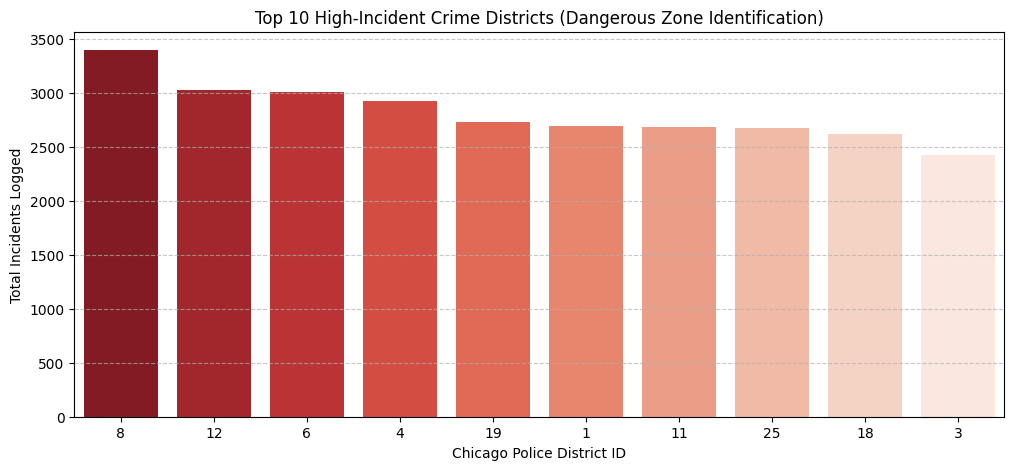

In [6]:
# District Crime Map (Dangerous Zone Identification)



# 1. Compute aggregate crime frequencies per District
district_counts = df['District'].value_counts().reset_index()
district_counts.columns = ['District', 'Crime_Count']

# Sort to identify the most dangerous districts
dangerous_districts = district_counts.sort_values(by='Crime_Count', ascending=False)

# 2. Generate graphical representation: Static Bar Chart
plt.figure(figsize=(12, 5))
sns.barplot(data=dangerous_districts.head(10), x='District', y='Crime_Count', palette='Reds_r', order=dangerous_districts.head(10)['District'])
plt.title("Top 10 High-Incident Crime Districts (Dangerous Zone Identification)")
plt.xlabel("Chicago Police District ID")
plt.ylabel("Total Incidents Logged")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# 3. Create interactive Map identifying District Centroids
district_map = folium.Map(location=chicago_center, zoom_start=10.5)

# Find center coordinates for each district to place an anchor flag
district_locations = df.groupby('District')[['Latitude', 'Longitude']].mean().reset_index()
district_summary = pd.merge(district_locations, dangerous_districts, on='District')

# Add indicators to the map for the Top 5 most dangerous districts
for _, row in district_summary.sort_values(by='Crime_Count', ascending=False).head(5).iterrows():
    folium.Marker(
        location=[row['Latitude'], row['Longitude']],
        popup=f"District: {int(row['District'])}<br>Total Crimes: {int(row['Crime_Count'])}",
        icon=folium.Icon(color='red', icon='exclamation-sign')
    ).add_to(district_map)

district_map


/tmp/ipykernel_3990/2948423535.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=dangerous_districts.head(10), x='District', y='Crime_Count', palette='Reds_r', order=dangerous_districts.head(10)['District'])


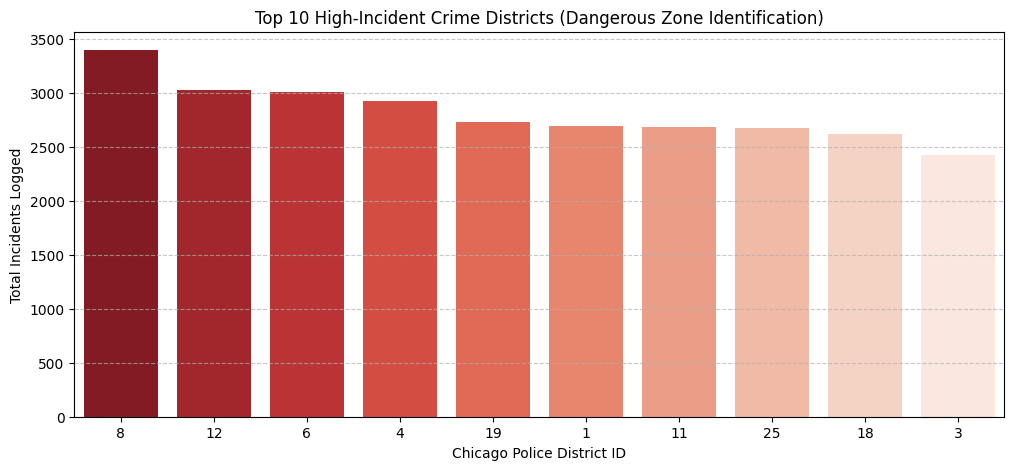

In [7]:
# District Crime Map (Dangerous Zone Identification)

# 1. Compute aggregate crime frequencies per District
district_counts = df['District'].value_counts().reset_index()
district_counts.columns = ['District', 'Crime_Count']

# Sort to identify the most dangerous districts
dangerous_districts = district_counts.sort_values(by='Crime_Count', ascending=False)

# 2. Generate graphical representation: Static Bar Chart
plt.figure(figsize=(12, 5))
sns.barplot(data=dangerous_districts.head(10), x='District', y='Crime_Count', palette='Reds_r', order=dangerous_districts.head(10)['District'])
plt.title("Top 10 High-Incident Crime Districts (Dangerous Zone Identification)")
plt.xlabel("Chicago Police District ID")
plt.ylabel("Total Incidents Logged")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# 3. Create interactive Map identifying District Centroids
district_map = folium.Map(location=chicago_center, zoom_start=10.5)

# Find center coordinates for each district to place an anchor flag
district_locations = df.groupby('District')[['Latitude', 'Longitude']].mean().reset_index()
district_summary = pd.merge(district_locations, dangerous_districts, on='District')

# Add indicators to the map for the Top 5 most dangerous districts
for _, row in district_summary.sort_values(by='Crime_Count', ascending=False).head(5).iterrows():
    folium.Marker(
        location=[row['Latitude'], row['Longitude']],
        popup=f"District: {int(row['District'])}<br>Total Crimes: {int(row['Crime_Count'])}",
        icon=folium.Icon(color='red', icon='exclamation-sign')
    ).add_to(district_map)

district_map








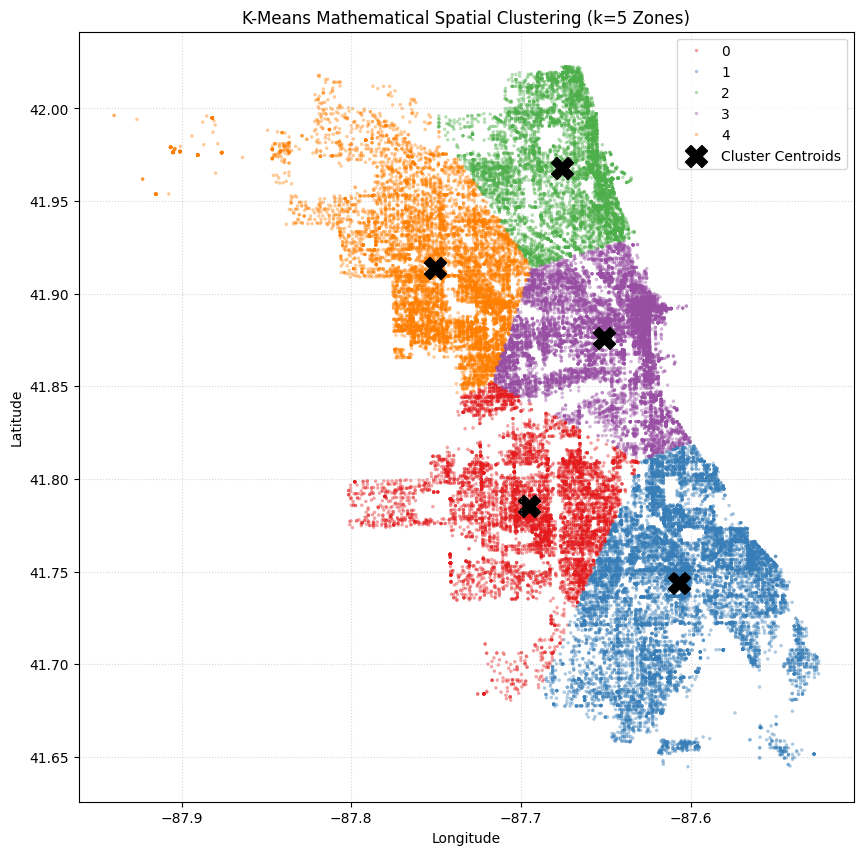

In [8]:
# K mean crime clustering

# \(K\)-Means is an unsupervised machine learning algorithm that groups spatial observations into distinct geographic clusters based on distance. Here, we partition the data into \(K=5\) clusters to mathematically identify major crime focal points across the city.



# 1. Extract coordinate vectors for the unsupervised model
spatial_features = df[['Latitude', 'Longitude']].dropna()

# 2. Instantiate and fit the K-Means cluster engine
num_clusters = 5
kmeans = KMeans(n_clusters=num_clusters, init='k-means++', random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(spatial_features)

# Extract spatial centers computed by the algorithm
centroids = kmeans.cluster_centers_

# 3. Generate graphical representation: Math-backed Scatter Plot
plt.figure(figsize=(10, 10))
# Scatter plot colored by cluster allocation
sns.scatterplot(
    data=df, x='Longitude', y='Latitude',
    hue='Cluster', palette='Set1',
    alpha=0.4, edgecolor=None, s=5
)
# Overlay the calculated mathematical cluster centroids as large black X markers
plt.scatter(
    centroids[:, 1], centroids[:, 0],
    marker='X', s=250, c='black',
    label='Cluster Centroids'
)

plt.title("K-Means Mathematical Spatial Clustering (k=5 Zones)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.5)
plt.show()
